In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [26]:
path = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir\train\2022_03_21_11_02_58_05.bmp"
# 1. Ler imagem e aplicar CLAHE
img_gray = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
clahe = cv2.createCLAHE(clipLimit=3.5, tileGridSize=(8,8))
img_contrast = clahe.apply(img_gray)

In [27]:
print(img_contrast)

[[ 77  81  85 ...  87  91  95]
 [ 85 110 102 ... 104 108 104]
 [ 94  94 102 ... 121 117 112]
 ...
 [ 98  98 115 ... 108 125 104]
 [107 111 111 ...  95 108 108]
 [119 124  98 ...  95 112 131]]


In [28]:
# 2. Inverter e aplicar colormap Twilight
img_color = cv2.applyColorMap(255 - img_contrast, cv2.COLORMAP_TWILIGHT)

In [29]:
# 3. Realçar nitidez
blur = cv2.GaussianBlur(img_color, (5,5), 1.0)
img_sharp = cv2.addWeighted(img_color, 1.5, blur, -0.5, 0)

In [30]:
# 4. Correção de gama
gamma = 0.8
img_gamma = np.power(img_sharp / 255.0, gamma)
img_final = np.uint8(255 * img_gamma)


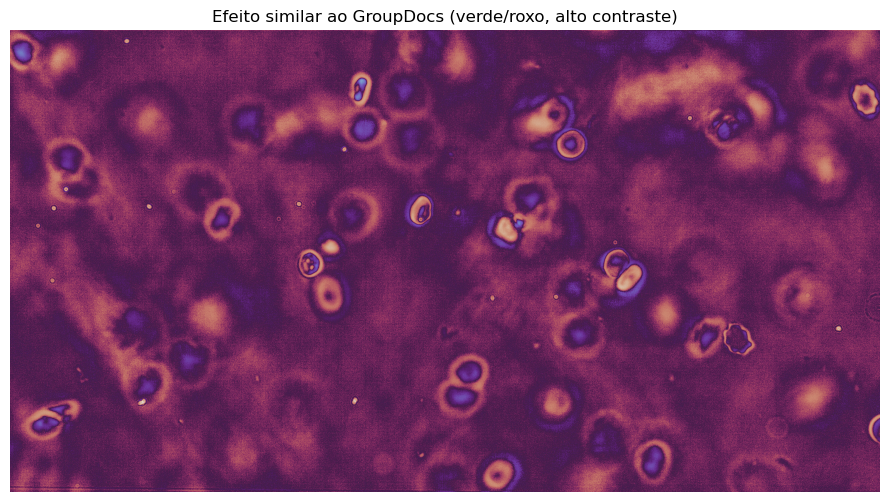

In [31]:
plt.figure(figsize=(12,6))
plt.imshow(cv2.cvtColor(img_final, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Efeito similar ao GroupDocs (verde/roxo, alto contraste)")
plt.show()

In [33]:
import cv2
import numpy as np
import os
from pathlib import Path

# ========================
# CONFIGURAÇÕES
# ========================
INPUT_IMAGE = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir\train\2022_03_21_11_02_58_05.bmp"      # caminho da imagem grande (a da direita)
OUTPUT_CELLS_DIR = "cells_recortadas"   # pasta onde vamos salvar os crops
OUTPUT_MASKS_DIR = "masks_binarias"     # pasta onde vamos salvar as máscaras das células (opcional)

Path(OUTPUT_CELLS_DIR).mkdir(exist_ok=True)
Path(OUTPUT_MASKS_DIR).mkdir(exist_ok=True)

# ========================
# 1. CARREGAR IMAGEM
# ========================
img_bgr = cv2.imread(INPUT_IMAGE)

# segurança caso OpenCV não carregue
if img_bgr is None:
    raise ValueError(f"Não consegui ler a imagem em {INPUT_IMAGE}")

# guardamos uma cópia em RGB só pra salvar recortes bonitos depois
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# ========================
# 2. PRÉ-PROCESSAMENTO
# ========================

# a) ir para tons de cinza (mesmo que seja colorido roxo/laranja)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# b) reduzir ruído mas manter borda
gray_blur = cv2.medianBlur(gray, 5)

# c) equalizar contraste local (CLAHE ajuda MUITO em microscopia)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
gray_eq = clahe.apply(gray_blur)

# ========================
# 3. LIMIARIZAÇÃO E LIMPEZA
# ========================

# Podemos tentar Otsu para separar "célula" vs "fundo"
# Obs: dependendo da coloração, pode ser invertido (célula escura / fundo claro)
_, thresh = cv2.threshold(gray_eq, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Se as células ficaram pretas e o fundo branco, invertemos:
# Queremos células = 255 (branco) para achar contornos
cell_is_dark = np.mean(gray_eq[thresh==255]) < np.mean(gray_eq[thresh==0])
if cell_is_dark:
    thresh = cv2.bitwise_not(thresh)

# d) Operações morfológicas:
# - Fechar pequenos buracos dentro da célula
# - Abrir para tirar ruído muito pequeno
kernel = np.ones((3,3), np.uint8)

# fecha buracos
thresh_closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
# remove sujeirinhas isoladas
thresh_clean = cv2.morphologyEx(thresh_closed, cv2.MORPH_OPEN, kernel, iterations=1)

# ========================
# 4. ENCONTRAR CONTORNOS
# ========================

contours, _ = cv2.findContours(thresh_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# parâmetros pra filtrar coisa inútil:
MIN_AREA = 80    # ajustar dependendo do zoom (área mínima em pixels)
MAX_AREA = 5000  # área máxima pra evitar recortar o campo inteiro ou clusters gigantes

cell_id = 0

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area < MIN_AREA or area > MAX_AREA:
        continue  # pula sujeira muito pequena ou manchas enormes

    x,y,w,h = cv2.boundingRect(cnt)

    # dá uma folga nas bordas pra pegar a célula inteira bonitinha
    pad = 5
    x0 = max(x - pad, 0)
    y0 = max(y - pad, 0)
    x1 = min(x + w + pad, img_rgb.shape[1])
    y1 = min(y + h + pad, img_rgb.shape[0])

    crop_rgb = img_rgb[y0:y1, x0:x1]          # recorte colorido
    crop_mask = thresh_clean[y0:y1, x0:x1]    # máscara binária correspondente

    # salva
    cell_filename = f"cell_{cell_id:04d}.png"
    mask_filename = f"mask_{cell_id:04d}.png"

    cv2.imwrite(os.path.join(OUTPUT_CELLS_DIR, cell_filename),
                cv2.cvtColor(crop_rgb, cv2.COLOR_RGB2BGR))  # voltar pra BGR pro OpenCV salvar
    cv2.imwrite(os.path.join(OUTPUT_MASKS_DIR, mask_filename),
                crop_mask)

    cell_id += 1

print(f"[FIM] Salvei {cell_id} células em {OUTPUT_CELLS_DIR} e máscaras em {OUTPUT_MASKS_DIR}")


[FIM] Salvei 24 células em cells_recortadas e máscaras em masks_binarias


In [34]:
import cv2
import numpy as np
import os
from pathlib import Path

# Caminhos
INPUT_IMAGE = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir\train\2022_03_21_11_02_58_05.bmp"       # a imagem com o "Giemsa artificial"
OUTPUT_DIR = "cells_giemsa_segmentadas"
Path(OUTPUT_DIR).mkdir(exist_ok=True)

# Carregar imagem
img = cv2.imread(INPUT_IMAGE)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w, _ = img.shape

# Converter para um vetor de pixels
pixels = img_rgb.reshape((-1, 3))
pixels = np.float32(pixels)

# K-means para separar cores dominantes (ex: fundo vs células)
# n_clusters = 3 costuma funcionar bem (fundo, núcleo, citoplasma)
k = 3
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 50, 0.2)
_, labels, centers = cv2.kmeans(pixels, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

# Converter resultado em imagem segmentada
segmented = centers[labels.flatten()]
segmented = segmented.reshape((h, w, 3)).astype(np.uint8)

# Escolher o cluster com menor intensidade média (núcleo roxo)
cluster_means = [np.mean(segmented[labels.reshape(h, w) == i]) for i in range(k)]
cell_cluster = np.argmin(cluster_means)

# Máscara binária das células
mask = np.uint8((labels.reshape(h, w) == cell_cluster) * 255)

# Fechar buracos e suavizar bordas
kernel = np.ones((3,3), np.uint8)
mask_clean = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

# Encontrar contornos das células
contours, _ = cv2.findContours(mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

cell_id = 0
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area < 80 or area > 5000:
        continue
    x,y,w,h = cv2.boundingRect(cnt)
    pad = 5
    x0, y0 = max(0, x - pad), max(0, y - pad)
    x1, y1 = min(w + x + pad, img.shape[1]), min(h + y + pad, img.shape[0])
    cell = img_rgb[y0:y1, x0:x1]
    cv2.imwrite(os.path.join(OUTPUT_DIR, f"cell_{cell_id:03d}.png"), cv2.cvtColor(cell, cv2.COLOR_RGB2BGR))
    cell_id += 1

print(f"[FIM] {cell_id} células segmentadas e salvas em {OUTPUT_DIR}")


[FIM] 65 células segmentadas e salvas em cells_giemsa_segmentadas


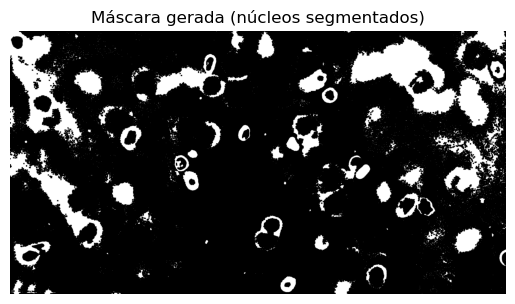

In [35]:
import matplotlib.pyplot as plt
plt.imshow(mask_clean, cmap='gray')
plt.title("Máscara gerada (núcleos segmentados)")
plt.axis('off')
plt.show()


In [36]:
import cv2
import numpy as np

# caminhos
giemsa_path = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\giemsa-artificial\train_giemsa\2022_03_21_11_02_58_05.png"   # imagem com coloração artificial
orig_path    = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir\train\2022_03_21_11_02_58_05.bmp"  # imagem original microscópio

img_giemsa_bgr = cv2.imread(giemsa_path)
img_orig_bgr   = cv2.imread(orig_path)

if img_giemsa_bgr is None or img_orig_bgr is None:
    raise RuntimeError("Erro lendo imagens. Verifique os caminhos.")

# vamos trabalhar em RGB para visualização/salvar depois
img_giemsa_rgb = cv2.cvtColor(img_giemsa_bgr, cv2.COLOR_BGR2RGB)
img_orig_rgb   = cv2.cvtColor(img_orig_bgr, cv2.COLOR_BGR2RGB)

h, w, _ = img_giemsa_rgb.shape

# ---- 1. Ir para espaço LAB para destacar diferença de cor (anel roxo/laranja)
lab = cv2.cvtColor(img_giemsa_bgr, cv2.COLOR_BGR2LAB)
L, A, B = cv2.split(lab)

# Muitas vezes RBC aparece com borda mais "quente" (tons de magenta/laranja),
# então o canal 'A' (verde<->magenta) costuma realçar bem as bordas.
canal = A

# ---- 2. Suavizar ruído mas manter borda
blur = cv2.medianBlur(canal, 5)

# ---- 3. Equalizar contraste localmente
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enh = clahe.apply(blur)

# ---- 4. Threshold Otsu
_, thresh = cv2.threshold(enh, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Dependendo da polaridade, pode ser que RBC saia preto e fundo branco:
# Queremos células = branco
mean_fg = np.mean(enh[thresh == 255]) if np.any(thresh==255) else 999
mean_bg = np.mean(enh[thresh == 0])   if np.any(thresh==0)   else 0
if mean_fg < mean_bg:
    thresh = cv2.bitwise_not(thresh)

# ---- 5. Limpeza morfológica
kernel = np.ones((3,3), np.uint8)
mask_clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)
mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_CLOSE, kernel, iterations=2)

# ---- 6. Encontrar candidatos a célula (contornos)
contours, _ = cv2.findContours(mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Heurísticas de área pra ignorar ruído e clusters gigantes
MIN_AREA = 100     # ajusta conforme zoom
MAX_AREA = 8000

cells_info = []
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area < MIN_AREA or area > MAX_AREA:
        continue

    x, y, ww, hh = cv2.boundingRect(cnt)

    # padding pra pegar a célula inteira
    pad = 5
    x0 = max(x - pad, 0)
    y0 = max(y - pad, 0)
    x1 = min(x + ww + pad, w)
    y1 = min(y + hh + pad, h)

    cells_info.append({
        "bbox": (x0, y0, x1, y1),
        "contour": cnt
    })

print(f"Detectamos {len(cells_info)} células candidatas.")


Detectamos 55 células candidatas.


In [37]:
import nibabel as nib
import numpy as np
import os

nii_path = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\annot_dir_cintia\train_segmentadas\2022_03_21_11_02_58_05.nii.gz"
out_cells_dir = "cells_recortadas"
os.makedirs(out_cells_dir, exist_ok=True)

nii_img = nib.load(nii_path)
nii_data = nii_img.get_fdata()  # vira um array numpy float64

# Agora precisamos transformar isso em 2D.
# Muitos scanners salvam como [H, W] ou [H, W, 1] ou [1, H, W].
# Vamos tentar espremer pra 2D:
mask_nii = np.squeeze(nii_data)

# Checar se a dimensão bate com a imagem
if mask_nii.shape != (h, w):
    print("ATENÇÃO: a máscara NIfTI não bate no tamanho da imagem!")
    print("mask_nii shape:", mask_nii.shape, "image shape:", (h, w))
    # Se não bate, depois a gente ajusta com resize ou affine. Mas vamos continuar assumindo que bate.

# Binarizar a máscara (infectado = 1 se valor > 0)
mask_infect = (mask_nii > 0).astype(np.uint8)  # 0/1
mask_infect_255 = (mask_infect * 255).astype(np.uint8)

infected_count = 0
clean_count = 0

for i, cell in enumerate(cells_info):
    x0, y0, x1, y1 = cell["bbox"]

    crop_color = img_orig_bgr[y0:y1, x0:x1]   # você pode usar img_giemsa_bgr se preferir coloração artificial
    crop_mask_inf = mask_infect[y0:y1, x0:x1]

    # heurística: se mais de X% dos pixels dentro da bbox estão marcados como infectado,
    # classificamos essa célula como infectada
    inf_ratio = crop_mask_inf.mean()  # como é 0/1, isso já é proporção
    infected = inf_ratio > 0.02  # 2% arbitrário; ajuste depois

    label = "infected" if infected else "clean"
    if infected:
        infected_count += 1
    else:
        clean_count += 1

    out_path = os.path.join(out_cells_dir, f"cell_{i:04d}_{label}.png")
    cv2.imwrite(out_path, crop_color)

print(f"Células infectadas salvas: {infected_count}")
print(f"Células limpas salvas: {clean_count}")
print(f"Total salvo: {infected_count + clean_count}")


ATENÇÃO: a máscara NIfTI não bate no tamanho da imagem!
mask_nii shape: (2048, 1088, 11) image shape: (1088, 2048)
Células infectadas salvas: 0
Células limpas salvas: 55
Total salvo: 55


C:\Users\sthem\AppData\Local\Temp\ipykernel_35000\2174687025.py:38: RuntimeWarning: Mean of empty slice.
  inf_ratio = crop_mask_inf.mean()  # como é 0/1, isso já é proporção
c:\Users\sthem\anaconda3\envs\swin_transformer\lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
